## DATA INSPECTION

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [2]:
# === Load a ColorMNIST dataset (LL + HL) ===
import torch, os, glob

# auto-detect all generated datasets under data/
DATASETS = sorted(
    d for d in glob.glob("data/cmnist*")
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "dll_samples.pkl"))
)
print("Available datasets:")
for i, d in enumerate(DATASETS):
    print(f"  [{i}] {d}")

# --- Select which dataset to inspect ---
SELECT = 0  # <-- change this index to pick dataset
DATA_DIR = DATASETS[SELECT]
print(f"\n📦 Using dataset: {DATA_DIR}")

# --- Load data files ---
Dll_samples = torch.load(os.path.join(DATA_DIR, "dll_samples.pkl"))
Dhl_samples = torch.load(os.path.join(DATA_DIR, "dhl_samples.pkl"))
omega_labels = torch.load(os.path.join(DATA_DIR, "intervention_mapping.pkl"))

# convenience aliases (for backward compatibility)
Dll_samples[None] = Dll_samples.get("obs", next(iter(Dll_samples.values())))
omega = {k: k for k in omega_labels.keys()}

# preview structure
print(f"DLL keys: {list(Dll_samples.keys())[:5]}")
print("Example LL shapes for 'obs':")
imgs, shapes, digits, colors = Dll_samples["obs"]
print("  images:", imgs.shape, "| shapes:", shapes.shape)
print("Example HL shape for 'obs':", Dhl_samples["obs"].shape)


Available datasets:
  [0] data/cmnist
  [1] data/cmnist16_c00_clean
  [2] data/cmnist16_c25_clean
  [3] data/cmnist16_c50_clean
  [4] data/cmnist16_c85_clean
  [5] data/cmnist32_c000_noise0
  [6] data/cmnist32_c000_noise1
  [7] data/cmnist32_c000_noise10
  [8] data/cmnist32_c000_noise11
  [9] data/cmnist32_c000_noise12
  [10] data/cmnist32_c000_noise13
  [11] data/cmnist32_c000_noise14
  [12] data/cmnist32_c000_noise15
  [13] data/cmnist32_c000_noise16
  [14] data/cmnist32_c000_noise2
  [15] data/cmnist32_c000_noise3
  [16] data/cmnist32_c000_noise4
  [17] data/cmnist32_c000_noise5
  [18] data/cmnist32_c000_noise6
  [19] data/cmnist32_c000_noise7
  [20] data/cmnist32_c000_noise8
  [21] data/cmnist32_c000_noise9
  [22] data/cmnist32_c00_clean
  [23] data/cmnist32_c25_clean
  [24] data/cmnist32_c50_clean
  [25] data/cmnist32_c85_clean
  [26] data/cmnist8_c00_clean
  [27] data/cmnist8_c25_clean
  [28] data/cmnist8_c50_clean
  [29] data/cmnist8_c85_clean
  [30] data/cmnist_28_c00_clean
  [

In [3]:
# === Interactive CMNIST inspector (widgets + live output) ===
import os, glob, torch, numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- discover datasets ---
DATASETS = sorted(
    d for d in glob.glob("data/cmnist*")
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "dll_samples.pkl"))
)
if not DATASETS:
    raise RuntimeError("No datasets found under data/. Generate with cmnist_gen_new.py first.")

# UI controls
ds_dropdown   = widgets.Dropdown(
    options=[(os.path.basename(d), d) for d in DATASETS],
    value=DATASETS[0], description="Dataset:", style={"description_width":"120px"},
    layout=widgets.Layout(width="400px")
)
iv_dropdown   = widgets.Dropdown(
    options=[], description="Intervention:", style={"description_width":"120px"},
    layout=widgets.Layout(width="400px")
)
view_toggle   = widgets.ToggleButtons(
    options=[("Triplets (images)","triplets"), ("HL z-summary hist","hist")],
    value="triplets", description="", layout=widgets.Layout(width="400px")
)
n_slider      = widgets.IntSlider(
    value=5, min=3, max=10, step=1, description="# samples:",
    style={"description_width":"120px"}, layout=widgets.Layout(width="400px")
)
out = widgets.Output()

# state
Dll_samples = None
Dhl_samples = None
omega_labels = None

def _load_dataset(folder):
    global Dll_samples, Dhl_samples, omega_labels
    Dll_samples = torch.load(os.path.join(folder, "dll_samples.pkl"))
    Dhl_samples = torch.load(os.path.join(folder, "dhl_samples.pkl"))
    omega_labels = torch.load(os.path.join(folder, "intervention_mapping.pkl"))

def _render():
    with out:
        clear_output(wait=True)
        if Dll_samples is None or omega_labels is None:
            print("No dataset loaded.")
            return

        # pick observational + chosen intervention
        obs_images, obs_shapes, obs_digits, obs_colors = Dll_samples["obs"]
        iota = iv_dropdown.value
        if iota not in Dll_samples:
            print(f"Intervention '{iota}' not found in Dll_samples keys: {list(Dll_samples.keys())}")
            return
        int_images, int_shapes, int_digits, int_colors = Dll_samples[iota]

        if view_toggle.value == "triplets":
            n = min(n_slider.value, len(obs_digits), len(int_digits))
            fig, axes = plt.subplots(3, n, figsize=(3*n, 7))
            if n == 1:
                axes = np.array([[axes[0]], [axes[1]], [axes[2]]])  # normalize shape

            for i in range(n):
                # Row 1: original grayscale ([-1,1] -> [0,1])
                shape = obs_shapes[i].squeeze()
                axes[0, i].imshow((shape + 1) / 2, cmap="gray")
                axes[0, i].set_title(f"Original\nDigit: {obs_digits[i].item()}")
                axes[0, i].axis("off")

                # Row 2: observational colored ([0,1])
                img = obs_images[i].permute(1, 2, 0).clamp(0, 1)
                axes[1, i].imshow(img)
                axes[1, i].set_title(f"Obs\nD: {obs_digits[i].item()}  C: {obs_colors[i].item()}")
                axes[1, i].axis("off")

                # Row 3: intervention colored ([0,1])
                int_img = int_images[i].permute(1, 2, 0).clamp(0, 1)
                axes[2, i].imshow(int_img)
                axes[2, i].set_title(f"Intv {iota}\nD: {int_digits[i].item()}  C: {int_colors[i].item()}")
                axes[2, i].axis("off")

            axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes,
                            rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

        else:  # "hist" — HL z-summary four-way comparison
            # HL layout now: [10 digit one-hot | 10 color one-hot | 64-dim z]
            def hl_z_norm(entry: torch.Tensor):
                # entry: (N, 84) or similar
                z = entry[:, 20:]          # last 64 dims = z
                return torch.linalg.norm(z, dim=1).numpy()

            def get(key): return Dhl_samples[key]

            # Pick standard quartet
            obs_values       = hl_z_norm(get("obs"))
            # Default IVs; fall back if keys missing
            digit_key = "D=8"      if "D=8"      in Dhl_samples else list(Dhl_samples.keys())[1]
            color_key = "C=0"      if "C=0"      in Dhl_samples else [k for k in Dhl_samples if k.startswith("C=")][0]
            both_key  = "D=8,C=0"  if "D=8,C=0"  in Dhl_samples else [k for k in Dhl_samples if "," in k][0]

            int_digit_vals    = hl_z_norm(get(digit_key))
            int_color_vals    = hl_z_norm(get(color_key))
            int_both_vals     = hl_z_norm(get(both_key))

            plt.figure(figsize=(12, 7))
            plt.hist(obs_values,      bins=50, alpha=0.50, density=True, label='Observational',        color='blue')
            plt.hist(int_digit_vals,  bins=50, alpha=0.70, density=True, label=f'do({digit_key})',     color='orange')
            plt.hist(int_color_vals,  bins=50, alpha=0.70, density=True, label=f'do({color_key})',     color='green')
            plt.hist(int_both_vals,   bins=50, alpha=0.85, density=True, label=f'do({both_key})',      color='purple')
            plt.title(f'HL z-norm distribution — {os.path.basename(ds_dropdown.label)}')
            plt.xlabel('‖z‖₂'); plt.ylabel('Density')
            plt.grid(ls='--', alpha=0.5); plt.legend()
            plt.show()

            # Stats
            print("--- Distribution Statistics for HL z-norm ---")
            print("Observational:")
            print(f"  Mean: {obs_values.mean():.4f} | Std: {obs_values.std():.4f}")
            print(f"{digit_key}:")
            print(f"  Mean: {int_digit_vals.mean():.4f} | Std: {int_digit_vals.std():.4f}")
            print(f"{color_key}:")
            print(f"  Mean: {int_color_vals.mean():.4f} | Std: {int_color_vals.std():.4f}")
            print(f"{both_key}:")
            print(f"  Mean: {int_both_vals.mean():.4f} | Std: {int_both_vals.std():.4f}")

def _on_change_dataset(change):
    folder = change["new"]
    _load_dataset(folder)
    all_labels = list(omega_labels.keys())
    iv_dropdown.options = all_labels
    # choose a sensible default intervention (digital one if present)
    iv_dropdown.value = "D=6" if "D=6" in all_labels else all_labels[1]
    _render()

def _on_change_intervention(change):
    _render()

def _on_change_controls(change):
    _render()

# wire events
ds_dropdown.observe(_on_change_dataset, names="value")
iv_dropdown.observe(_on_change_intervention, names="value")
view_toggle.observe(_on_change_controls, names="value")
n_slider.observe(_on_change_controls, names="value")

# first load + display
_load_dataset(ds_dropdown.value)
iv_dropdown.options = list(omega_labels.keys())
iv_dropdown.value = "D=6" if "D=6" in iv_dropdown.options else iv_dropdown.options[1]
controls = widgets.VBox([ds_dropdown, iv_dropdown, widgets.HBox([view_toggle, n_slider])])
display(controls, out)
_render()


Output()

z shape: (10000, 64)


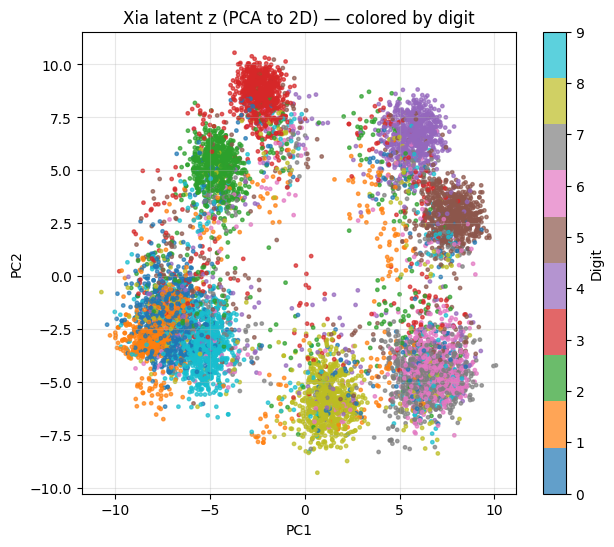

In [4]:
# === Visualize Xia's latent z (PCA to 2D) ===
from sklearn.decomposition import PCA

if Dhl_samples is None or Dll_samples is None:
    raise RuntimeError("Run the previous cell to load a dataset first.")

# HL layout: [10 digit one-hot | 10 color one-hot | 64-dim z]
hl_obs = Dhl_samples["obs"]               # (N, 84)
ll_obs = Dll_samples["obs"]               # (images, shapes, digits, colors)

digits = ll_obs[2].numpy()               # (N,)
colors = ll_obs[3].numpy()               # (N,)
z = hl_obs[:, 20:].numpy()               # (N, 64)  (last 64 dims)

print("z shape:", z.shape)

# PCA to 2D for visualization
pca = PCA(n_components=2)
z2 = pca.fit_transform(z)

plt.figure(figsize=(7, 6))
sc = plt.scatter(z2[:, 0], z2[:, 1], c=digits, cmap="tab10", s=6, alpha=0.7)
plt.colorbar(sc, label="Digit")
plt.title("Xia latent z (PCA to 2D) — colored by digit")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


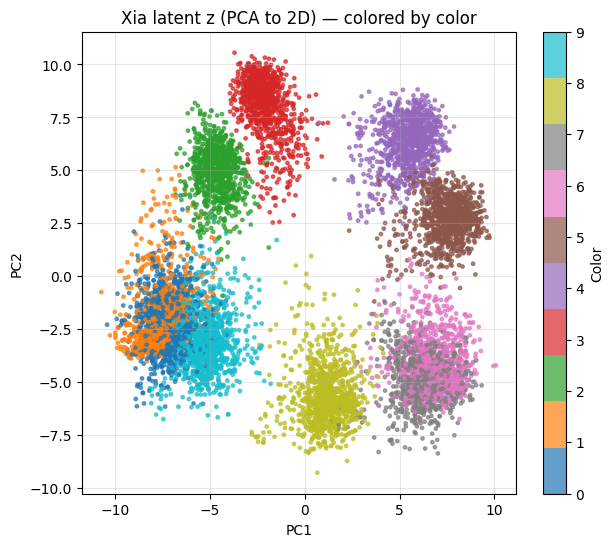

In [5]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(z2[:, 0], z2[:, 1], c=colors, cmap="tab10", s=6, alpha=0.7)
plt.colorbar(sc, label="Color")
plt.title("Xia latent z (PCA to 2D) — colored by color")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()


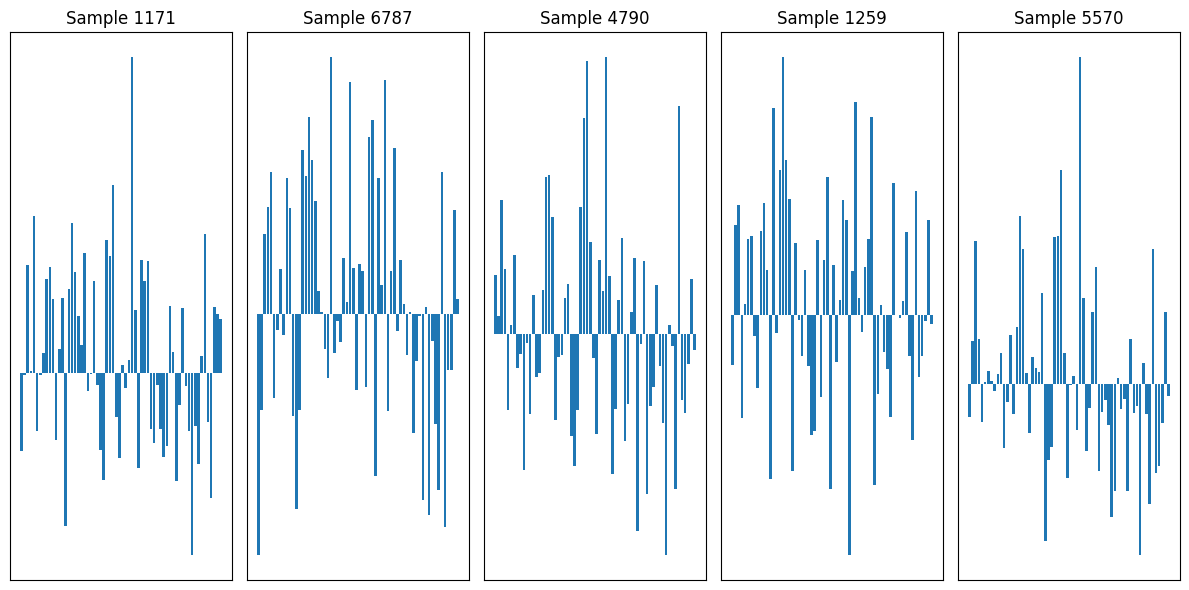

In [6]:
# Visualize the z-vector of a few samples (no PCA)
import matplotlib.pyplot as plt
import numpy as np

z_obs = Dhl_samples["obs"][:, 20:]     # shape (N,64)
idx = np.random.choice(len(z_obs), 5)

plt.figure(figsize=(12, 6))
for i, j in enumerate(idx):
    plt.subplot(1, 5, i+1)
    plt.bar(np.arange(64), z_obs[j])
    plt.title(f"Sample {j}")
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()


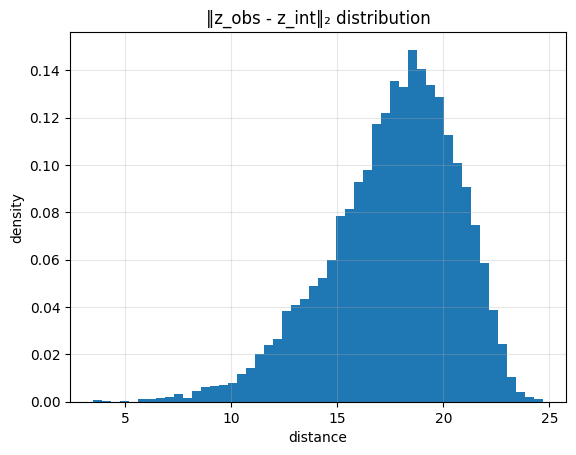

In [7]:
# Compare observational vs intervention z (L2-distance)
z_obs  = Dhl_samples["obs"][:, 20:]
z_int  = Dhl_samples["D=6"][:, 20:]   # example intervention

dist = torch.linalg.norm(z_obs - z_int, dim=1).numpy()

plt.hist(dist, bins=50, density=True)
plt.title("‖z_obs - z_int‖₂ distribution")
plt.xlabel("distance")
plt.ylabel("density")
plt.grid(alpha=0.3)
plt.show()
